# Qiskit 101

In this notebook we will go through how to build and run a quantum circuit on Qiskit.

In [8]:
# basic imports
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

First of all, we have to determine the size in qubits of our circuit. In this example we will create a BELL state, so we need 2 qubits.
Since we will measure these two qubits at the end, we also need two classical bits to store the measurement results. 

In [9]:
# Our two qubits are created as a 2-qubits register
qr = QuantumRegister(2)

# We initialize our circuit with the registers we defined
bell_circ = QuantumCircuit(qr)

As you already know, all qubits are initialized to the ground state $\vert0\rangle$. How can we apply some quantum gates?

If the gate we want to apply is a well-known gate (e.g. H, Z, X, CNOT), we can simply use some methods provided by the QuantumCircuit class. Otherwise, we can apply an arbitrary QuantumGate or Instruction to our circuit (we will see this later). See [QuantumCircuit docs](https://qiskit.org/documentation/stubs/qiskit.circuit.QuantumCircuit.html) for details.

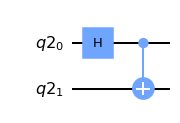

In [10]:
bell_circ.h(qr[0])
bell_circ.cx(qr[0], qr[1])
bell_circ.draw(output="mpl")

When we are planning to reuse the same series of gates many times, we can wrap it into a single gate or instruction and apply it as a whole when needed:

In [15]:
bell = bell_circ.to_instruction(label="BELL")

## A few words about Qiskit state representation

When dealing with multi qubit states, Qiskit uses a **Big Endian** representation.

For example, given the states $\vert001\rangle$ and $\vert01\rangle$, Qiskit would represent this states as $\vert100\rangle$ and $\vert10\rangle$.

This difference in labeling affects the way multi-qubit operations are represented as matrices. For example, let's take the well-known matrix for the CNOT gate: $CNOT=\begin{pmatrix}1&0&0&0 \\ 0&1&0&0 \\ 0&0&0&1 \\ 0&0&1&0\end{pmatrix}$. In Qiskit this matrix is represented as $CNOT_{qiskit}=\begin{pmatrix}1&0&0&0 \\ 0&0&0&1 \\ 0&0&1&0 \\ 0&1&0&0\end{pmatrix}$. To obtain the Qiskit matrix, we can start from the standard matrix and permute the second and third rows and columns, because $\vert01\rangle$ and $\vert10\rangle$ states are "flipped". This can easily be generalized to matrices of any size.

### How does this affect us?

Qiskit internal representation is not a big deal for us, we just have to remember that if we define a multi-qubit unitary gate from a matrix, we have to permute some rows and columns to turn it into Qiskit representation.

In common use, we can use Qiskit without considering its internal "flipped" representation at all, but we must remember that when we measure $n$ qubits, we must store the measurement results in $n$ classical bits **in reversed order** to restore our Little Endian labels (I'll show you how later).

## Let's go back to our circuit

At this point we have our BELL gate that maps the CBS $\{\vert00\rangle\, \vert01\rangle\, \vert10\rangle\, \vert11\rangle\}$ to the Bell basis $\{\vert\beta_{00}\rangle\, \vert\beta_{01}\rangle\, \vert\beta_{10}\rangle\, \vert\beta_{11}\rangle\}$.

Let's build a new circuit and play with our Bell states. Since we want to measure our two qubits at the end, we also define a 2-bits ClassicalRegister to store our measurement results:

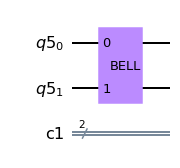

In [16]:
# Our two classical bits are created as a 2-bits register
cr = ClassicalRegister(2)

qr = QuantumRegister(2)

circ = QuantumCircuit(qr, cr)

circ.append(bell, qr[:])

circ.draw(output="mpl")

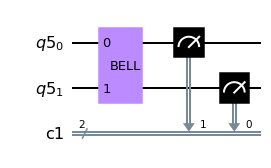

In [17]:
"""
we add a measurement at the end for each qubit, notice that I store the output of qubit 0 in bit 1 and vice versa,
to cope with Qiskit flipped labels.
"""
circ.measure(qr[0], cr[1])
circ.measure(qr[1], cr[0])

circ.draw(output="mpl")

The output state of this circuit (pre-measurement) is $\vert\beta_{00}\rangle = \frac{\vert00\rangle + \vert11\rangle}{\sqrt{2}}$, so we expect to measure "00" or "11" with 50% probability each.

## Execute a circuit with Qiskit

To execute a circuit with Qiskit we need to define three things:
* **Provider**: The service which will provide us with a backend. Commonly, it's either Aer or IBM-Q
* **Backend**: The device on which the job will run, it may be a real quantum computer (only with IBM-Q) or a simulator.
* **Job**: Our circuit together with some additional information, like the number of independent *shots*. It can be seen as a task ready to be executed on a specific backend.

In [19]:
# In this example we use Aer as provider. 
# Thus, the backend will be installed as a virtual machine on our local device
from qiskit import Aer

# We get a qasm simulator as backend from Aer
backend = Aer.get_backend('qasm_simulator')


Before being ready to execute our circuit, we must transpile it into an equivalent circuit composed only by gates supported by the backend we chose. Remember I told you that each quantum device has its set of instructions! See [transpile docs](https://qiskit.org/documentation/stubs/qiskit.compiler.transpile.html) for details.

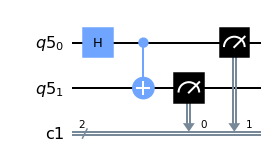

In [20]:
from qiskit.compiler import transpile
tr_circ = transpile(circ, backend, optimization_level=1)

tr_circ.draw(output="mpl")

In [21]:
# We define our job
job = backend.run(tr_circ, shots=2048)

# We execute and collect the results:
result = job.result()

# We collect the measurements in a dictionary
counts = result.get_counts()

print(counts)

{'11': 1038, '00': 1010}


## Visualizing results

Qiskit visualization has many graphic tools that help us visualize circuit results. See [Qiskit Visualization docs](https://qiskit.org/documentation/tutorials/circuits/2_plotting_data_in_qiskit.html) for details.

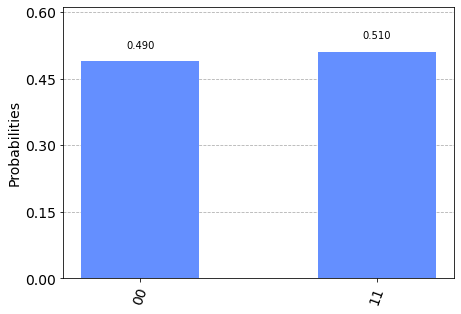

In [37]:
from qiskit.visualization import plot_histogram

plot_histogram(counts)

## Exercise

### Using the BELL gate we defined before, try to build and run a QuantumCircuit that outputs the Bell state $\vert\beta_{11}\rangle = \frac{\vert01\rangle - \vert10\rangle}{\sqrt{2}}$ and measures the output

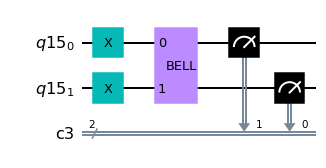

In [23]:
# hint: you have to obtain the CBS state |11> and then apply the BELL gate.
# hint: the NOT (or X) gate can be applied on a QuantumCircuit by using the method circuit.x(qubit)

# Our two classical bits are created as a 2-bits register
cr = ClassicalRegister(2)

qr = QuantumRegister(2)

circ = QuantumCircuit(qr, cr)

circ.x(qr[0])
circ.x(qr[1])

circ.append(bell, qr[:])

circ.measure(qr[0], cr[1])
circ.measure(qr[1], cr[0])

circ.draw(output="mpl")

tr_circ = transpile(circ, backend, optimization_level=1)

